# KNN Model

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve, auc
)

## Load Metadata and Paths

In [2]:
#  Load metadata
train_df = pd.read_csv("train_augmented_metadata.csv")
val_df = pd.read_csv("val_metadata.csv")
test_df = pd.read_csv("test_metadata.csv")

In [3]:
train_image_dir = "augmented_photos/train"
val_test_image_dir = "resized_photos"

## Image Loading and Feature Extraction

In [4]:
def load_images(df, image_dir, suffix="", verbose=False):
    X, y, extra = [], [], []
    for _, row in df.iterrows():
        photo_id = row['photo_id']
        if suffix and photo_id.endswith(suffix):
            filename = f"{photo_id}.jpg"
        else:
            filename = f"{photo_id}{suffix}.jpg"
        path = os.path.join(image_dir, filename)

        if os.path.exists(path):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (128, 128))
                flat = img.flatten()
                X.append(flat)
                y.append(row['label'])
                extra.append(np.mean(flat))
            elif verbose:
                print(f"[ERROR] Cannot read: {path}")
        elif verbose:
            print(f"[WARNING] Missing image: {path}")
    print(f"[INFO] Loaded {len(X)} images from: {image_dir}")
    return np.array(X), np.array(extra).reshape(-1, 1), np.array(y)


In [5]:
X_train, Xtrain_mean, y_train = load_images(train_df, "augmented_photos/train", "_aug", verbose=False)
X_val, Xval_mean, y_val = load_images(val_df, "resized_photos", verbose=False)
X_test, Xtest_mean, y_test = load_images(test_df, "resized_photos", verbose=False)


[INFO] Loaded 17192 images from: augmented_photos/train
[INFO] Loaded 2146 images from: resized_photos
[INFO] Loaded 2149 images from: resized_photos


In [6]:
#  Label Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

## Dimensionality Reduction with PCA

In [7]:
#  PCA
pca = PCA(n_components=150)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [8]:
#  Combine PCA + extra feature
X_train_final = np.hstack((X_train_pca, Xtrain_mean))
X_val_final = np.hstack((X_val_pca, Xval_mean))
X_test_final = np.hstack((X_test_pca, Xtest_mean))

##  kNN Model Training

## Grid Search for Best kNN Parameters

In [9]:
# 🔍 kNN Tuning with GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [10]:
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy', verbose=1)
grid.fit(X_train_final, y_train_enc)
best_knn = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


## Model Evaluation: Accuracy and AUC

In [11]:
#  Evaluate on Test Set
y_pred = best_knn.predict(X_test_final)
y_proba = best_knn.predict_proba(X_test_final)

print("Test Accuracy:", accuracy_score(y_test_enc, y_pred))

Test Accuracy: 0.3941368078175896


In [12]:
#  AUC Score
y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_train_enc))
auc_score = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
print("Multiclass AUC Score:", auc_score)

Multiclass AUC Score: 0.7070750530120249


In [13]:
# Accuracy Scores
train_acc = best_knn.score(X_train_final, y_train_enc)
val_acc = best_knn.score(X_val_final, y_val_enc)
test_acc = best_knn.score(X_test_final, y_test_enc)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.5337366216845044
Validation Accuracy: 0.40773532152842495
Test Accuracy: 0.3941368078175896


In [14]:
#  Classification Report
print("Test Classification Report:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

Test Classification Report:
               precision    recall  f1-score   support

       drink       0.35      0.42      0.38       507
        food       0.42      0.33      0.37       495
      inside       0.49      0.28      0.36       496
        menu       0.24      0.43      0.31       152
     outside       0.45      0.54      0.49       499

    accuracy                           0.39      2149
   macro avg       0.39      0.40      0.38      2149
weighted avg       0.41      0.39      0.39      2149



In [15]:
# Predict on train data
y_train_pred = best_knn.predict(X_train_final)

# Confusion matrix for train
cm_train = confusion_matrix(y_train_enc, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le.classes_)
print("Train Classification Report:\n", classification_report(y_train_enc, y_train_pred, target_names=le.classes_))

Train Classification Report:
               precision    recall  f1-score   support

       drink       0.50      0.58      0.54      3971
        food       0.60      0.49      0.54      4006
      inside       0.66      0.42      0.51      4023
        menu       0.35      0.61      0.44      1191
     outside       0.53      0.62      0.58      4001

    accuracy                           0.53     17192
   macro avg       0.53      0.54      0.52     17192
weighted avg       0.56      0.53      0.53     17192



## Confusion Matrix

<Figure size 800x600 with 0 Axes>

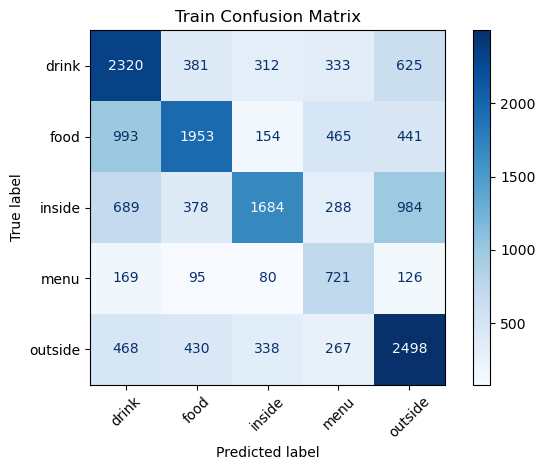

In [16]:

# Predict on train data
y_train_pred = best_knn.predict(X_train_final)

# Confusion matrix for train
cm_train = confusion_matrix(y_train_enc, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le.classes_)

# Plot
plt.figure(figsize=(8, 6))
disp_train.plot(cmap="Blues", xticks_rotation=45)
plt.title("Train Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

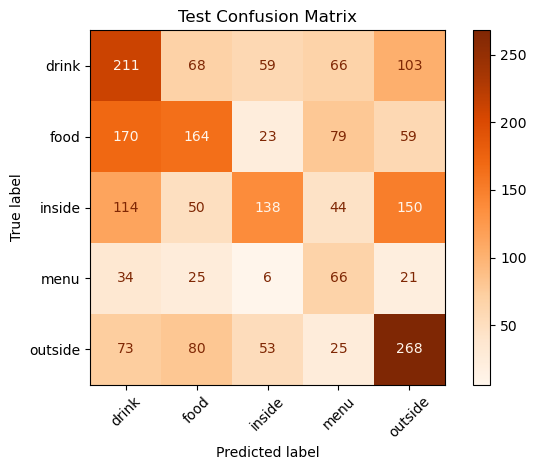

In [17]:
# Predict on test data
y_test_pred = best_knn.predict(X_test_final)

# Confusion matrix for test
cm_test = confusion_matrix(y_test_enc, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)

# Plot
plt.figure(figsize=(8, 6))
disp_test.plot(cmap="Oranges", xticks_rotation=45)
plt.title("Test Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


## AUC - ROC Curve

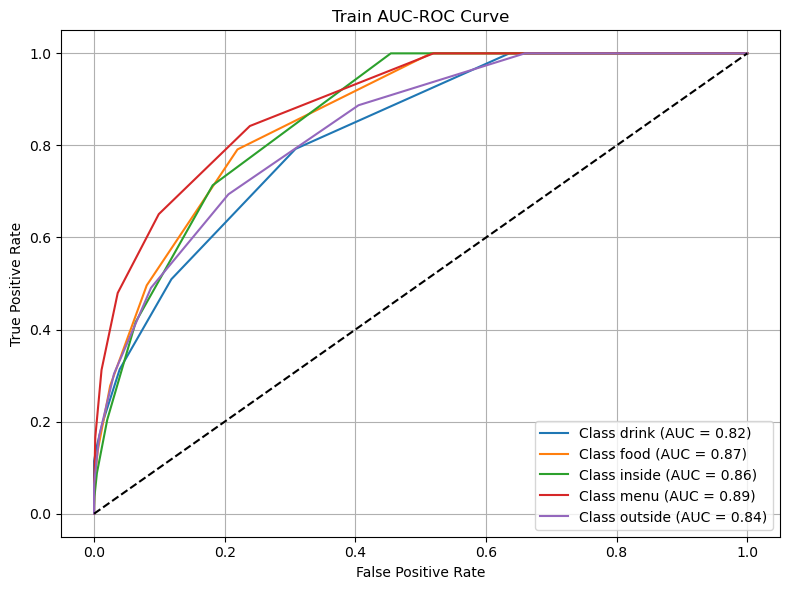

In [18]:
# Binarize train labels
classes = np.unique(y_train_enc)
y_train_bin = label_binarize(y_train_enc, classes=classes)

# Predict probabilities using best_knn
y_train_proba = best_knn.predict_proba(X_train_final)

# Plot Train ROC
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Train AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()


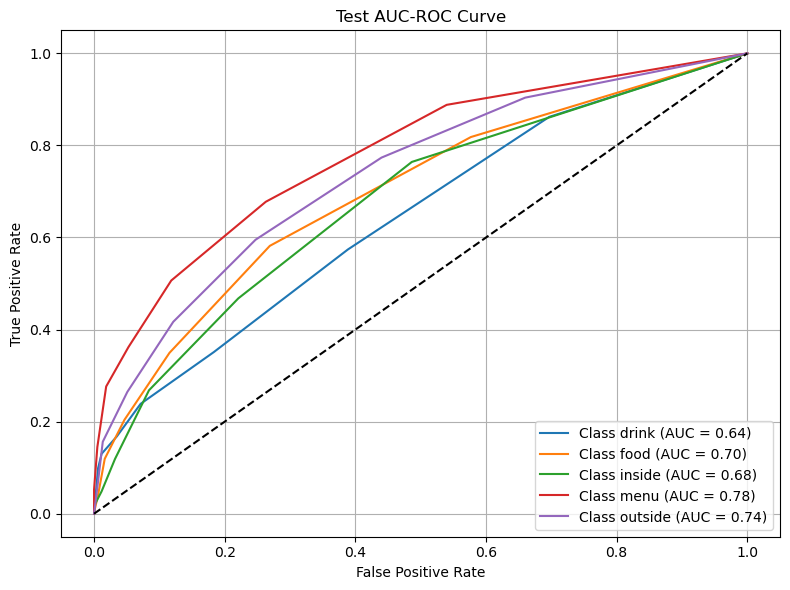

In [19]:
# Binarize test labels
y_test_bin = label_binarize(y_test_enc, classes=classes)

# Predict probabilities
y_test_proba = best_knn.predict_proba(X_test_final)

# Plot Test ROC
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Test AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()


## Class Separability Visualization with PCA

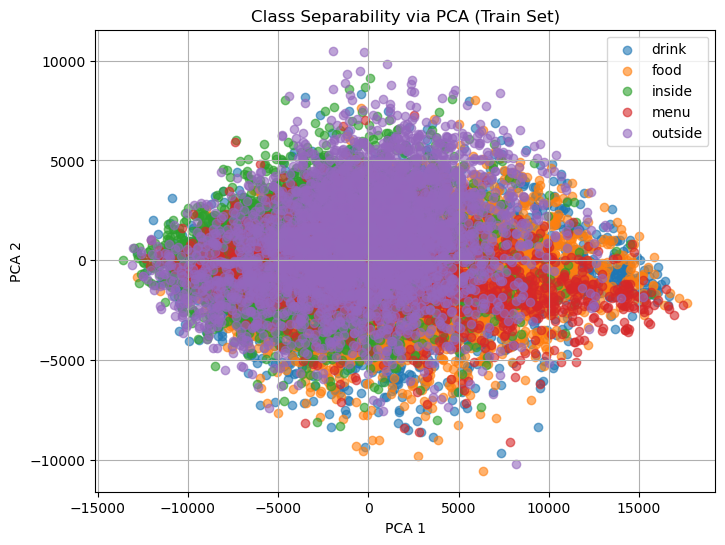

In [20]:
plt.figure(figsize=(8, 6))
for label in np.unique(y_train_enc):
    idx = y_train_enc == label
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], label=le.inverse_transform([label])[0], alpha=0.6)
plt.title("Class Separability via PCA (Train Set)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


**Low Class Separability**  
   - PCA visualization shows significant overlap between classes such as `inside`, `outside`, and `menu`.
   - This affects the model’s ability to distinguish between similar classes and reduces accuracy.


In [22]:
from lime.lime_tabular import LimeTabularExplainer

# Create the tabular LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train_final,
    feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])] + ['Brightness'],
    class_names=le.classes_,
    mode='classification'
)

# Choose a test sample to explain
sample_index = 0
sample_data = X_test_final[sample_index]
sample_label = y_test_enc[sample_index]

# Explain the prediction
exp = explainer.explain_instance(
    data_row=sample_data,
    predict_fn=best_knn.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook(show_table=True)


##  LIME Interpretability

Applied LIME to study which PCA features influenced the kNN model’s predictions.

However, because our features were abstract PCA components (not interpretable image parts), the output was not visually meaningful.

Still, this showed that the model’s decisions rely heavily on a few dominant components which confirming that feature quality limits interpretability.
